0. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

0. Import Datasets

In [3]:
dayEvents = pd.read_csv('./dataset/World Important Dates.csv')
goldPrice = pd.read_csv('./dataset/Gold 1979-2021.csv')

In [4]:
dayEvents.head()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,Unknown,2600 BC,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
1,2,Battle of the Ten Kings,Unknown,Unknown,1400 BC,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
2,6,Establishment of the Delhi Sultanate,Unknown,Unknown,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed
3,7,Battle of Panipat,21,April,1526,India,Battle,Panipat,Foundation of the Mughal Empire in India,Northern Indian kingdoms,Babur,Mixed
4,8,Establishment of British Raj,1,May,1858,India,Colonial,Whole India,Start of direct British governance in India,Indian subcontinent,British East India Company/Empire,Negative


In [5]:
goldPrice.head()

,Date,United States(USD),Europe(EUR),Japan(JPY),United Kingdom(GBP),Canada(CAD),Switzerland(CHF),India(INR),China(CNY),Turkey(TRY),Saudi Arabia(SAR),Indonesia(IDR),United Arab Emirates(AED),Thailand(THB),Vietnam(VND),Egypt(EGP),South Korean(KRW),Australia(AUD),South Africa(ZAR)
0,31-01-1979,233.7,144.8,45160.3,117.4,267.1,379.3,1840.8,NaN,NaN,745.2,139739.3,856.1,4511.3,NaN,NaN,108235.8,197.2,194.5
1,28-02-1979,251.3,154.6,50209.1,124.2,295.5,413.6,2011.7,NaN,NaN,827.8,154683.1,946.6,4985.7,NaN,NaN,119929.3,219.6,209.4
2,30-03-1979,240.1,148.0,50274.3,116.2,278.2,406.2,1940.2,NaN,NaN,796.7,148844.2,910.4,4812.9,NaN,NaN,116123.6,214.6,202.4
3,30-04-1979,245.3,152.8,54144.6,118.8,278.5,420.0,2013.1,NaN,NaN,819.4,152453.6,930.2,4891.0,NaN,NaN,117423.3,221.1,206.9
4,31-05-1979,274.6,172.0,61057.1,132.7,321.6,478.0,2253.4,NaN,NaN,933.3,171656.1,1048.4,5560.8,NaN,NaN,133889.6,250.7,233.7


## DayEvents Managing


1. แปลง Month และ Year ใน dayEvents

In [6]:
def formatYear(x):
    if 'BC' in x:
        return int(x.replace(' BC', '')) * -1
    return int(x)

In [7]:
dayEvents['Year'] = dayEvents['Year'].apply(formatYear)

In [8]:
dayEvents['Month'].unique()

array(['Unknown', 'April', 'May', 'August', 'December', 'November',
       'June', 'October', 'February', 'July', 'January', 'March',
       'September'], dtype=object)

In [9]:
monthMap = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

def formatMonth(x):
    if x in monthMap:
        return int(monthMap[x])
    else:
        return np.nan

In [10]:
dayEvents['Month'] = dayEvents['Month'].apply(formatMonth).astype('Int64', errors='ignore')

In [11]:
dayEvents.head()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,<NA>,-2600,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
1,2,Battle of the Ten Kings,Unknown,<NA>,-1400,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
2,6,Establishment of the Delhi Sultanate,Unknown,<NA>,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed
3,7,Battle of Panipat,21,4,1526,India,Battle,Panipat,Foundation of the Mughal Empire in India,Northern Indian kingdoms,Babur,Mixed
4,8,Establishment of British Raj,1,5,1858,India,Colonial,Whole India,Start of direct British governance in India,Indian subcontinent,British East India Company/Empire,Negative


ใน GoldPrice ใช้ column - Date, Price(USD), Price(THB) 

In [12]:
goldPrice.head()

,Date,United States(USD),Europe(EUR),Japan(JPY),United Kingdom(GBP),Canada(CAD),Switzerland(CHF),India(INR),China(CNY),Turkey(TRY),Saudi Arabia(SAR),Indonesia(IDR),United Arab Emirates(AED),Thailand(THB),Vietnam(VND),Egypt(EGP),South Korean(KRW),Australia(AUD),South Africa(ZAR)
0,31-01-1979,233.7,144.8,45160.3,117.4,267.1,379.3,1840.8,NaN,NaN,745.2,139739.3,856.1,4511.3,NaN,NaN,108235.8,197.2,194.5
1,28-02-1979,251.3,154.6,50209.1,124.2,295.5,413.6,2011.7,NaN,NaN,827.8,154683.1,946.6,4985.7,NaN,NaN,119929.3,219.6,209.4
2,30-03-1979,240.1,148.0,50274.3,116.2,278.2,406.2,1940.2,NaN,NaN,796.7,148844.2,910.4,4812.9,NaN,NaN,116123.6,214.6,202.4
3,30-04-1979,245.3,152.8,54144.6,118.8,278.5,420.0,2013.1,NaN,NaN,819.4,152453.6,930.2,4891.0,NaN,NaN,117423.3,221.1,206.9
4,31-05-1979,274.6,172.0,61057.1,132.7,321.6,478.0,2253.4,NaN,NaN,933.3,171656.1,1048.4,5560.8,NaN,NaN,133889.6,250.7,233.7


1. แยกส่วนของ Date เก็บแยกไว้ของ GoldPrice

In [13]:
goldPrice['Date'] = pd.to_datetime(goldPrice['Date'], format='%d-%m-%Y')

# แยกเป็น 3 ส่วน
goldPrice['Day'] = goldPrice['Date'].dt.day
goldPrice['Month'] = goldPrice['Date'].dt.month
goldPrice['Year'] = goldPrice['Date'].dt.year

In [14]:
goldPrice.head()

,Date,United States(USD),Europe(EUR),Japan(JPY),United Kingdom(GBP),Canada(CAD),Switzerland(CHF),India(INR),China(CNY),Turkey(TRY),...,United Arab Emirates(AED),Thailand(THB),Vietnam(VND),Egypt(EGP),South Korean(KRW),Australia(AUD),South Africa(ZAR),Day,Month,Year
0,1979-01-31,233.7,144.8,45160.3,117.4,267.1,379.3,1840.8,NaN,NaN,...,856.1,4511.3,NaN,NaN,108235.8,197.2,194.5,31,1,1979
1,1979-02-28,251.3,154.6,50209.1,124.2,295.5,413.6,2011.7,NaN,NaN,...,946.6,4985.7,NaN,NaN,119929.3,219.6,209.4,28,2,1979
2,1979-03-30,240.1,148.0,50274.3,116.2,278.2,406.2,1940.2,NaN,NaN,...,910.4,4812.9,NaN,NaN,116123.6,214.6,202.4,30,3,1979
3,1979-04-30,245.3,152.8,54144.6,118.8,278.5,420.0,2013.1,NaN,NaN,...,930.2,4891.0,NaN,NaN,117423.3,221.1,206.9,30,4,1979
4,1979-05-31,274.6,172.0,61057.1,132.7,321.6,478.0,2253.4,NaN,NaN,...,1048.4,5560.8,NaN,NaN,133889.6,250.7,233.7,31,5,1979


2. สร้าง DataFrame เก็บข้อมูลเฉพาะที่ต้องการ
- ในที่นี้จะใช้ Day, Month, Year, Price(USD), Price(THB)

In [15]:
goldPrice.columns

Index(['Date', 'United States(USD)', 'Europe(EUR)', 'Japan(JPY)',
       'United Kingdom(GBP)', 'Canada(CAD)', 'Switzerland(CHF)', 'India(INR)',
       'China(CNY)', 'Turkey(TRY)', 'Saudi Arabia(SAR)', 'Indonesia(IDR)',
       'United Arab Emirates(AED)', 'Thailand(THB)', 'Vietnam(VND)',
       'Egypt(EGP)', 'South Korean(KRW)', 'Australia(AUD)',
       'South Africa(ZAR)', 'Day', 'Month', 'Year'],
      dtype='object')

In [19]:
newGoldPrice = goldPrice[['Day','Month','Year','United States(USD)','Thailand(THB)']]
newGoldPrice.rename(columns={'United States(USD)': 'Price(USD)', 'Thailand(THB)': 'Price(THB)'}, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_41628\27009988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newGoldPrice.rename(columns={'United States(USD)': 'Price(USD)', 'Thailand(THB)': 'Price(THB)'}, inplace=True)


In [20]:
newGoldPrice.head()

,Day,Month,Year,Price(USD),Price(THB)
0,31,1,1979,233.7,4511.3
1,28,2,1979,251.3,4985.7
2,30,3,1979,240.1,4812.9
3,30,4,1979,245.3,4891.0
4,31,5,1979,274.6,5560.8


In [18]:
dayEvents.head()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,<NA>,-2600,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
1,2,Battle of the Ten Kings,Unknown,<NA>,-1400,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
2,6,Establishment of the Delhi Sultanate,Unknown,<NA>,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed
3,7,Battle of Panipat,21,4,1526,India,Battle,Panipat,Foundation of the Mughal Empire in India,Northern Indian kingdoms,Babur,Mixed
4,8,Establishment of British Raj,1,5,1858,India,Colonial,Whole India,Start of direct British governance in India,Indian subcontinent,British East India Company/Empire,Negative


In [21]:
dayEvents = dayEvents.sort_values(by='Year')
dayEvents.head()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,<NA>,-2600,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
772,810,Stonehenge Completion,Unknown,<NA>,-2500,UK,Prehistoric Monument,Salisbury Plain,Creation of iconic Neolithic monument,Ancient Britons,Neolithic builders,Positive
518,555,Hammurabi's Code of Laws,Unknown,<NA>,-1754,Babylon,Legal Code Introduction,Babylon,Introduction of one of the earliest written le...,Babylonian citizens,Hammurabi,Positive
1,2,Battle of the Ten Kings,Unknown,<NA>,-1400,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
1082,1138,Establishment of the Olmec Civilization,Unknown,<NA>,-1400,Mexico,Cultural,Gulf Coast,Development of the first major civilization in...,Indigenous populations,Unknown,Positive


In [22]:
newGoldPrice = newGoldPrice.sort_values(by='Year')
newGoldPrice.head()

,Day,Month,Year,Price(USD),Price(THB)
0,31,1,1979,233.7,4511.3
11,31,12,1979,512.0,10645.2
10,30,11,1979,415.7,8260.5
9,31,10,1979,382.0,7808.0
7,31,8,1979,315.1,6424.5


In [27]:
filtered_dayEvents = dayEvents[(dayEvents['Year'] >= 1979) & (dayEvents['Year'] <= 2021)]

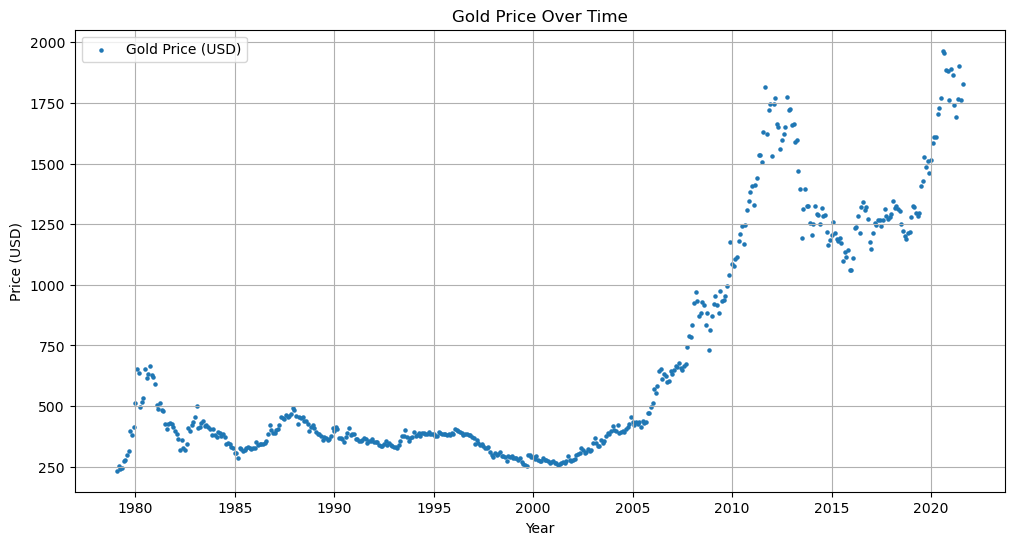

In [ ]:
newGoldPrice['Date'] = pd.to_datetime(newGoldPrice[['Year', 'Month', 'Day']])

# 2. Plot โดยใช้ Date เป็นแกน X
plt.figure(figsize=(12, 6))
plt.scatter(newGoldPrice['Date'], newGoldPrice['Price(USD)'], label='Gold Price (USD)', s=5)
plt.scatter()

# 3. ตกแต่งกราฟ
plt.title('Gold Price Over Time')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

In [63]:
# สร้าง Pivot Table
pivot_df = filtered_dayEvents.pivot_table(
    index=['Year'],      # แถว: เรียงตามปีและเดือน
    columns='Type of Event',      # คอลัมน์: แยกตามประเภท Event
    aggfunc='size',               # การคำนวณ: 'size' คือการนับจำนวนแถว (Count)
    fill_value=0                  # ถ้าเดือนไหนไม่มี Event นั้นให้ใส่ 0 แทน NaN
)

print(pivot_df.head())

Type of Event  Accident  Administrative  Administrative Change  \
Year                                                             
1979                  0               0                      0   
1980                  0               0                      0   
1981                  0               0                      0   
1982                  0               0                      0   
1983                  1               0                      0   

Type of Event  AntiUnknownCorruption Effort  Aviation  Civil Unrest  \
Year                                                                  
1979                                      0         0             0   
1980                                      0         0             0   
1981                                      0         0             0   
1982                                      0         0             0   
1983                                      0         0             0   

Type of Event  Civil War  Commemoration

In [ ]:
dayEvents['Date'].unique()

array(['Unknown', '264', '4', '509', '10', '25', '27', '15', '20', '18',
       '8', '29', '19', '9', '1', '3', '31', '12', '22', '13', '21', '6',
       '24', '14', '26', '7', '2', '             ', '11', '23', '5', '16',
       '30', '28', '17', '1904', '1917', '1936', '6 and 9', '1956',
       '1972', 'October', '23Unknown25', '1998', '2004', 'March'],
      dtype=object)

In [71]:
filtered_dayEvents['Date'].unique()

array(['Unknown', '20', '24', '18', '6', '22', '2', '17', '25', '23',
       '10', '4', '29', '1', '3', '12', '9', '28', '15', '7', '26', '8',
       '11', '21', '16', '             ', '30', 23, '27', '19', '5',
       '1998', '13', '31', '2004', '14', 'March'], dtype=object)

In [72]:
filtered_dayEvents[filtered_dayEvents['Date'] == 'Unknown'] 

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
495,531,Speak Mandarin Campaign Launched,Unknown,<NA>,1979,Singapore,Cultural Policy,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive
571,609,1979 Iranian Revolution,Unknown,2,1979,Iran,Revolution,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed
159,174,OneUnknownChild Policy Introduced,Unknown,<NA>,1979,China,Population Control Policy,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed
573,611,IranUnknownIraq War,Unknown,9,1980,Iraq,Military Conflict,Iraq/Iran border,"Attempted to dominate the Persian Gulf region,...","Iraqi, Iranian citizens",Saddam Hussein,Negative
355,384,1981 Springbok Tour Protests,Unknown,<NA>,1981,New Zealand,Social Unrest,New Zealand,AntiUnknownapartheid protests against the Sout...,"Protesters, rugby fans",AntiUnknownApartheid Movements,Mixed
...,...,...,...,...,...,...,...,...,...,...,...,...
1029,1085,Amazon Rainforest Wildfires,Unknown,8,2019,Brazil,Environmental,Amazon Rainforest,International attention on Brazil's environmen...,Global and local environment,Various stakeholders,Negative
1081,1137,Legalization of Abortion,Unknown,12,2020,Argentina,Legal,Argentina,Legalization of abortion up to the 14th week o...,Argentinians,Argentine Legislature,Positive
423,454,COVIDUnknown19 Pandemic Response,Unknown,<NA>,2020,Vietnam,Health Crisis,Vietnam,Vietnam's effective early response to the COVI...,Vietnamese people,Vietnamese Government,Positive
46,50,Asiatic Lion Census Showing Population Increase,Unknown,5,2020,India,Wildlife Conservation,Gujarat,"Indicated successful conservation efforts, wit...",Asiatic lions,"Wildlife Conservationists, Government of Gujarat",Positive


In [70]:
filtered_dayEvents.loc[
    filtered_dayEvents['Date'] == '23Unknown25', 
    'Date'
] = 23

In [75]:
filtered_dayEvents[filtered_dayEvents['Month'].isnull()]

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
495,531,Speak Mandarin Campaign Launched,Unknown,<NA>,1979,Singapore,Cultural Policy,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive
159,174,OneUnknownChild Policy Introduced,Unknown,<NA>,1979,China,Population Control Policy,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed
355,384,1981 Springbok Tour Protests,Unknown,<NA>,1981,New Zealand,Social Unrest,New Zealand,AntiUnknownapartheid protests against the Sout...,"Protesters, rugby fans",AntiUnknownApartheid Movements,Mixed
1000,1056,Abolition of Slavery Enforced,Unknown,<NA>,1981,Mauritania,Legal,Mauritania,"Criminalization of slavery, though challenges ...",Mauritanians,Mauritanian Government,Mixed
133,143,Sigiriya Designated as a UNESCO World Heritage...,Unknown,<NA>,1982,Sri Lanka,Cultural Heritage,Sigiriya,Recognition of the ancient rock fortress for i...,Global and local tourists,UNESCO,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
90,100,FATF Grey List,Unknown,<NA>,2018,Pakistan,International Finance,"Paris, France",Pakistan placed on the 'grey list' by the Fina...,Pakistani economy,Financial Action Task Force (FATF),Negative
1078,1134,Economic Crisis and IMF Loan,Unknown,<NA>,2018,Argentina,Economic,Argentina,Severe economic crisis leading to the largest ...,Argentinians,"Mauricio Macri, IMF",Negative
423,454,COVIDUnknown19 Pandemic Response,Unknown,<NA>,2020,Vietnam,Health Crisis,Vietnam,Vietnam's effective early response to the COVI...,Vietnamese people,Vietnamese Government,Positive
755,793,COVIDUnknown19 Pandemic in the UK,March,<NA>,2020,UK,Health,London and nationwide,Significant impact on public health and economy,British population,UK Government,Negative


In [76]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 18
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              1096 non-null   int64 
 1   Name of Incident                    1096 non-null   object
 2   Date                                1096 non-null   object
 3   Month                               701 non-null    Int64 
 4   Year                                1096 non-null   int64 
 5   Country                             1096 non-null   object
 6   Type of Event                       1096 non-null   object
 7   Place Name                          1096 non-null   object
 8   Impact                              1096 non-null   object
 9   Affected Population                 1096 non-null   object
 10  Important Person/Group Responsible  1096 non-null   object
 11  Outcome                             1096 non-null   object
dtyp

In [ ]:
filtered_dayEvents.info()
# 1979 - 2021

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 495 to 625
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              389 non-null    int64 
 1   Name of Incident                    389 non-null    object
 2   Date                                389 non-null    object
 3   Month                               324 non-null    Int64 
 4   Year                                389 non-null    int64 
 5   Country                             389 non-null    object
 6   Type of Event                       389 non-null    object
 7   Place Name                          389 non-null    object
 8   Impact                              389 non-null    object
 9   Affected Population                 389 non-null    object
 10  Important Person/Group Responsible  389 non-null    object
 11  Outcome                             389 non-null    object
dt

In [78]:
filtered_dayEvents.describe()

,Sl. No,Month,Year
count,389.00000,324.0,389.000000
mean,554.22108,6.762346,2004.354756
std,350.09940,3.492008,12.276144
min,11.00000,1.0,1979.000000
25%,247.00000,4.0,1994.000000
50%,611.00000,7.0,2007.000000
75%,840.00000,10.0,2016.000000
max,1137.00000,12.0,2021.000000
